## Les modules à utiliser

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
import random

## Discretisation de x et t

In [4]:
def Paramètres_de_la_simulation(a,b,c1,d,Nt,Nx):
    h,k=(b-a)/(Nx-1),(d-c1)/(Nt-1)
    x=np.array([a+i*h for i in range(Nx)])
    t=np.array([c1+j*k for j in range(Nt)])
    return x,t,k,h

## Solution sur les bords

In [5]:
def solution_sur_le_bord(Nt,Nx,x,t,u_exacte):
    U = np.array([[None]*Nx]*Nt)#np.zeros((Nt,Nx))    #stockage des valeurs de u(x_i,t_j) 
    U_exacte=np.array([[None]*Nx]*Nt)#np.zeros((Nt,Nx))
    for i in range(Nx): 
        U[0,i]=f(x[i])       #solution sur le bords gamma_1 
        U_exacte[0,i]=f(x[i]) 
    for j in range(1,Nt):
        U[j,0]=f1(t[j])
        U[j,Nx-1]=f2(t[j])
        
        U_exacte[j,0]=f1(t[j])
        U_exacte[j,Nx-1]=f2(t[j])
    return U,U_exacte

##  construire de la solution globale (bords+ apprimation à intérieur du domaine)

In [98]:
def solution_et_approximation(U,U_exacte,x,t,c,k,h,Nt,Nx,g,u_exacte1):
    
    for i in range(1,Nx-1):
        U[1,i] =U[0,i]+k*g(x[i])+ 0.5*((k *c)/h)**2 * (U[0,i+1]- 2 * U[0,i] + U[0,i-1])
        U_exacte[1,i]=u_exacte1(x[i],t[0])
    
    for j in range(1,Nt-1):
        for i in range(1,Nx-1):
            U[j+1,i] =2*U[j,i]-U[j-1,i]+ 0.5*((k *c)/h)**2 * (U[j,i+1]- 2 * U[j,i] + U[j,i-1])
            U_exacte[j+1,i]=u_exacte1(x[i],t[j])
            U_approcher=U_exacte
    return U,U_approcher

## CONSTRUCTION DE LA SOLUTION DE EXACTE ET APPROCHER

In [99]:
def Graphe1D(U1,U_approcher):
    plt.figure(figsize=(14, 6))
    plt.subplot(1,2,1)
    for j in range(0, Nt,9):
        plt.plot(x, U_approcher[j, :], label=f"t = {t[j]:.2f}")
    plt.xlabel("Position dans l'espace (x)")
    plt.ylabel("Déplacement de l'ondes (u)")
    plt.title("Equation des ondes en 2D: Solution exacte")
    plt.legend()
    plt.subplot(1,2,2)
    for j in range(0, Nt,9):
        plt.plot(x, U[j, :], label=f"t = {t[j]:.2f}")
    plt.xlabel("Position dans l'espace (x)")
    plt.ylabel("Déplacement de l'ondes (u)")
    plt.title("Equation des ondes en 2D:Solution approcher")
    plt.legend()
    fu_exacte=plt.show()
    fu_aprocher=plt.show()
    return fu_exacte,fu_aprocher

## Graphe2d et 3d des solution

In [100]:
def Graphe3d_solution_exact(x,t,U_exact):
    X,T=np.meshgrid(x,t)
    Z=u_exacte(X,T)
    ax=plt.axes(projection='3d')
    ax.plot_surface(X,T,Z,cmap='viridis')
    return
    
def Graphe3d_solution_approcher(x,t,U):                   #plt.contour(X,T,Z,colors='black')  # on peut remplace contour par contourf et annulé colors
    ay=plt.axes(projection='3d')
    ay.plot_surface(x[:,None],t[:,None],U[:,:],cmap='viridis')
    return 

## APPLICATION

c=0.08874444175097601,h/k=1.5


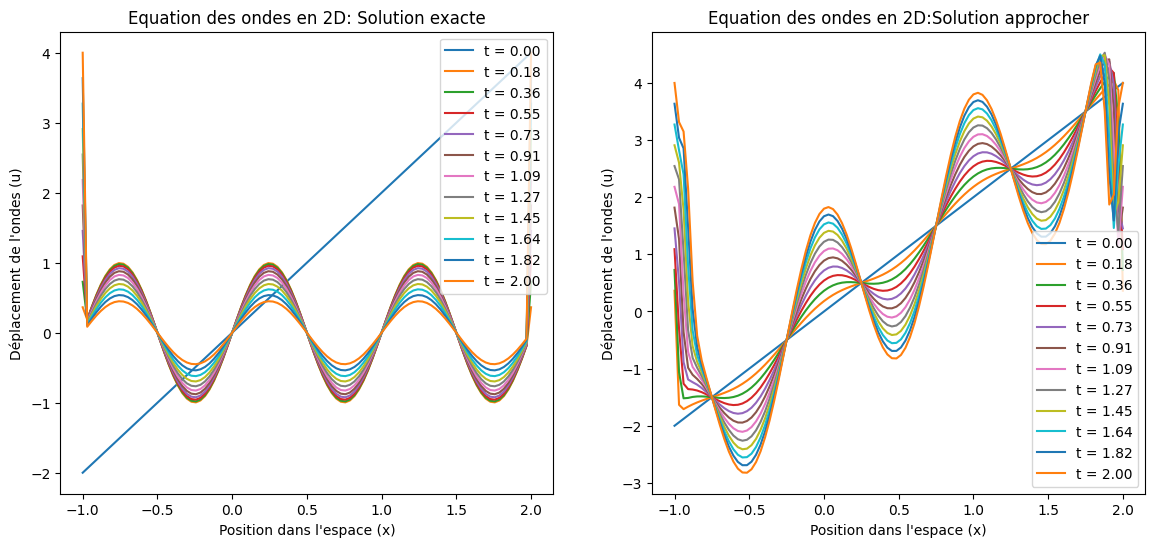

(None, None)

In [111]:
f=lambda x:2*x                                   #np.sin(2 * np.pi * x)  #sur le bord gamma_1
f1=lambda x:2*x                                 #sur le bord gamma_2
f2=lambda x:2*x                                #sur le bord gamma_3
g= lambda x:np.cos(2*np.pi*x)                 # la dérivée de u à l'instant t_0 (sur le bord gamma_2)

a,b=-1,2
c1,d=0,2
Nt,Nx=100,100
                 #solution 
u_exacte1=lambda x,t: 0.5*(np.sin(2*np.pi*(x-c*t))+np.sin(2*np.pi*(x+c*t)))                      #1ère exemple
x,t,k,h=Paramètres_de_la_simulation(a,b,c1,d,Nt,Nx)
c=np.random.uniform(0,h/k)   #condition de stabilité CFL
print(f'c={c},h/k={h/k}')
U,U_exacte1=solution_sur_le_bord(Nt,Nx,x,t,u_exacte1)
U1,U_approcher1=solution_et_approximation(U,U_exacte1,x,t,c,k,h,Nt,Nx,g,u_exacte1)
Graphe1D(U1,U_approcher1)

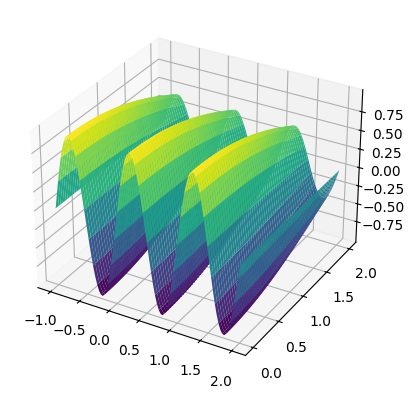

In [112]:
Graphe3d_solution_exact(x,t,U_approcher1)

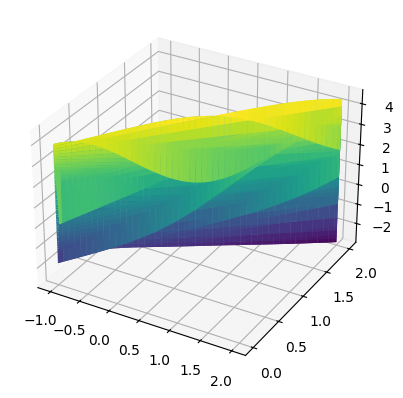

In [115]:
Graphe3d_solution_approcher(x,t,U1)

## 2ème exemple : meme domaine que précédement

c=0.29546005503704026,h/k=1.5


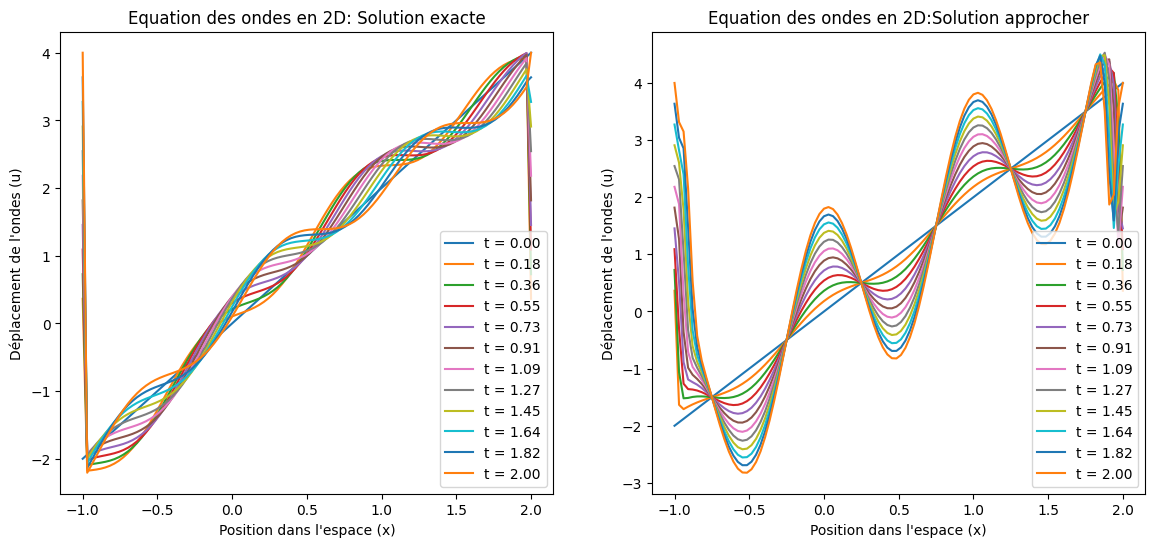

(None, None)

In [124]:
u_exacte2=lambda x,t: 2*x+(1/(4*c*np.pi))*(np.sin(2*c*np.pi*(x+c*t))-np.sin(2*np.pi*(x-c*t)))    
x,t,k,h=Paramètres_de_la_simulation(a,b,c1,d,Nt,Nx)
c=np.random.uniform(0,h/k)   #condition de stabilité CFL
print(f'c={c},h/k={h/k}')
U2,U_exacte2=solution_sur_le_bord(Nt,Nx,x,t,u_exacte2)
U2,U_approcher2=solution_et_approximation(U2,U_exacte2,x,t,c,k,h,Nt,Nx,g,u_exacte2)
Graphe1D(U2,U_approcher2)

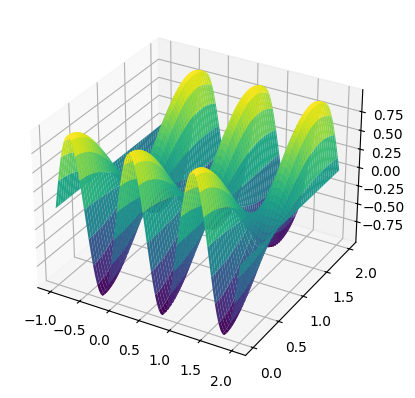

In [125]:
Graphe3d_solution_exact(x,t,U_approcher2)

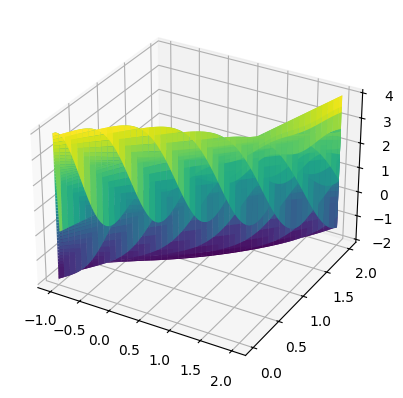

In [126]:
Graphe3d_solution_approcher(x,t,U2)


## Cas des problèmes ayant la initiale condition discontinu

In [133]:
def Graphe(U1,U_exacte):
    plt.figure(figsize=(14, 6))
    plt.subplot(1,2,1)
    for j in range(0, Nt,9):
        plt.plot(x, U_exacte[j, :], label=f"t = {t[j]:.2f}")
    plt.xlabel("Position dans l'espace (x)")
    plt.ylabel("Déplacement de l'ondes (u)")
    plt.title("Equation des ondes en 2D: Solution exacte")
    plt.legend()
    plt.subplot(1,2,2)
    for j in range(0, Nt,9):
        plt.plot(x, U[j, :], label=f"t = {t[j]:.2f}")
    plt.xlabel("Position dans l'espace (x)")
    plt.ylabel("Déplacement de l'ondes (u)")
    plt.title("Equation des ondes en 2D:Solution approcher")
    plt.legend()
    fu_exacte=plt.show()
    fu_aprocher=plt.show()
    
    return fu_exacte,fu_aprocher


In [152]:
def solution2(a,b,c1,d,Nt,Nx,fD,gDdt,gD):
    x,t,k,h=Paramètres_de_la_simulation(a,b,c1,d,Nt,Nx)
    c=np.random.uniform(0,h/k)   #condition de stabilité CFL
    print(f'c={c},h/k={h/k}')
    f=gD               #sur le bord gamma_1
    f1=gD             #sur le bord gamma_2
    f2=gD                #sur le bord gamma_3
    g=gDdt                # la dérivée de u à l'instant t_0 (sur le bord gamma_2)
    
    u_exacte=fD   #solution du problement discontinu
    
    U,U_exacte=solution_sur_le_bord(Nt,Nx,x,t,u_exacte)
    U,U_exacte=solution(U,U_exacte,x,t,c,k,h,Nt,Nx,g,u_exacte)
    return U,U_exacte

In [153]:
def fD(x,t):
    return np.where(x>c*t,1-(1/2*c)*(-x+c*t),np.where(x<-c*t,-1-t,(1/(2*c))*(-(-x+c*t)-2*(x+c*t))))
def gDdt(vars):
    x=vars
    return np.where(x>=0,-2,-1)
def gD(vars):
    x=vars
    return np.where(x>=0,1,-1)

c=-0.4679623283273704,h/k=-6.0


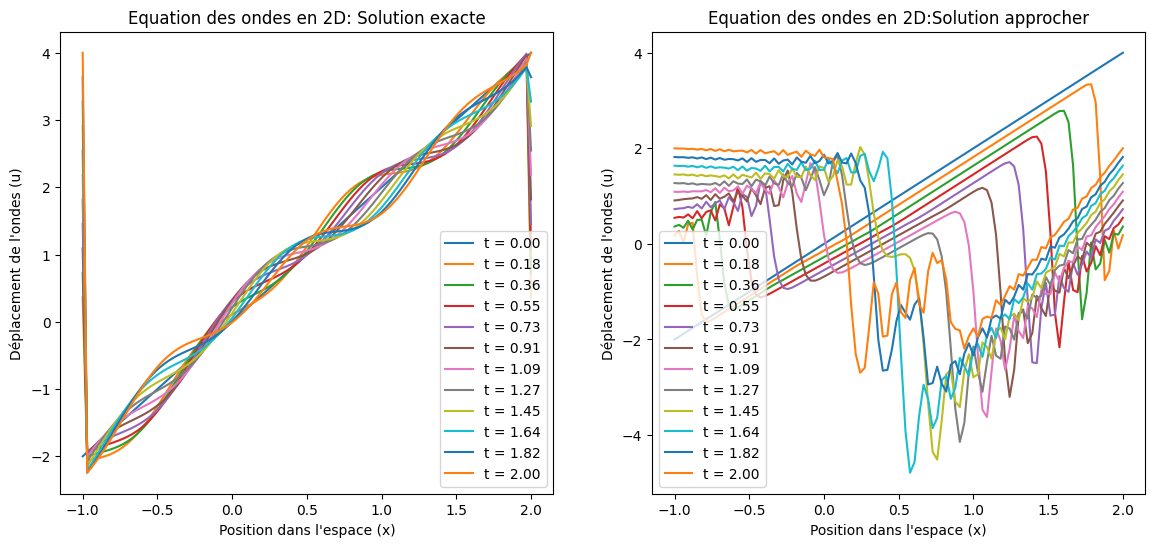

In [155]:
c,d=1,0
Nt,Nx=100,100
U2,U_exacte2= solution2(a,b,c1,d,Nt,Nx,fD,gDdt,gD)
fu_exacte,fu_aprocher=Graphe(U2,U_exacte2)

c=-1.3719303796348865,h/k=-6.0


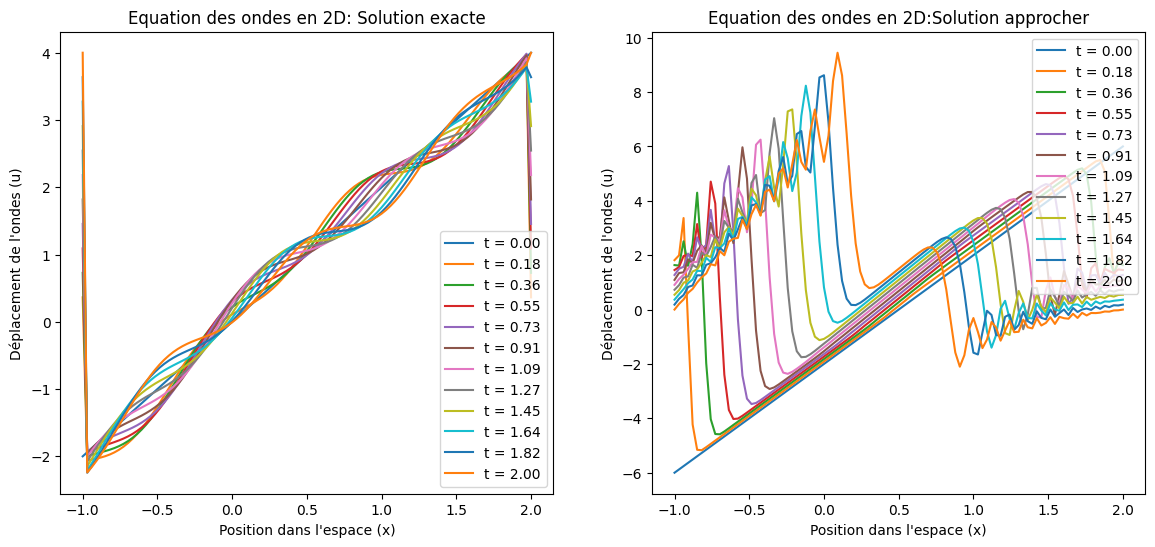

In [159]:
def fD(x,t):
    return np.where(x>c*t,1-(1/2*c)*(-x+c*t),np.where(x<-c*t,-1-t,(1/(2*c))*(-(-x+c*t)-2*(x+c*t))))
def gDdt(vars):
    x=vars
    return np.where(x>=0,-2,-1)
def gD(vars):
    x=vars
    return np.where(x>=0,1,-1)

c,d=1,0
Nt,Nx=100,100
U2,U_exacte2= solution2(a,b,c1,d,Nt,Nx,fD,gDdt,gD)
fu_exacte,fu_aprocher=Graphe(U2,U_exacte2)